# One Core's View of the Cache

Everything below is what a **single thread on a single core** can see. No sharing, no
coherence, no core-to-core transfer, no threads at all — those live in
[`cache_hierarchy.ipynb`](cache_hierarchy.ipynb). This notebook keeps only the properties you
need to reason about a **loop** and about **vectorising** it:

| | |
|---|---|
| **Capacity** | how big a working set can get before it falls out of each level — the number that sets a tile size |
| **Line size** | how much memory moves per access, which decides what a stride costs |
| **Latency** | what one miss costs, in cycles and in work forgone |
| **Bandwidth** | the ceiling a streaming loop runs into |
| **Vector width** | whether a wider register actually makes the loop faster |
| **Alignment** | what it costs when a vector load straddles two lines |
| **Associativity** | why a power-of-two array dimension can cost 24x |

Measured on an **AMD Ryzen AI 9 HX 370** (Zen 5), pinned to cpu0, with the core warmed before
every run — see [`harness.h`](harness.h). For the shape of the machine rather than its
behaviour, see [`block_diagram.html`](block_diagram.html). Every number is read from the `.csv` files the
benchmarks in this directory emit.

In [1]:
import csv, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
HERE = Path.cwd()

def load(name):
    with open(HERE / name) as f:
        return list(csv.DictReader(f))

lat    = load("latency.csv")          # cache_latency.c    -- latency vs working set
rowcol = load("row_column.csv")       # row_column.c       -- loop order and padding
_rows  = [r for r in csv.reader(open(HERE / "stride_bandwidth.csv")) if r]   # stride_bandwidth.c
stride = [r for r in _rows if r[0] == "stride"]
bw     = [r for r in _rows if r[0] == "bw"]
_vw    = [r for r in csv.reader(open(HERE / "vector_width.csv")) if r]       # vector_width.c
width  = [r for r in _vw if r[0] == "width"]     # tag, bytes, scalar, avx2, avx512
align  = [r for r in _vw if r[0] == "align"]     # tag, offset, avx512

def at(mode, target):
    """the measured row for `mode` whose working set is closest to `target` bytes"""
    rows = [r for r in lat if r["mode"] == mode]
    return min(rows, key=lambda r: abs(math.log(int(r["bytes"]) / target)))

print(f"{len(lat)} latency points, {len(stride)} strides, {len(width)} sizes x 3 widths")

78 latency points, 11 strides, 15 sizes x 3 widths


---
## 1. What one core has

Read from `/sys`, not from a datasheet. L1 and L2 belong to this core alone; the L3 is shared
with the three other cores in its complex, but from inside a single-threaded loop it is simply
*the last level before DRAM*, so it is listed here for its capacity and nothing else.

Nothing is measured here — the geometry is read straight from `/sys`, which is why this cell tells the truth if you run the notebook on a different machine.

The same geometry drawn as blocks — cores, split L1, private L2, the two L3s and main
memory — is in [`block_diagram.html`](block_diagram.html).

Source: `/sys/devices/system/cpu/cpu0/cache/` &middot; the harness shared by every benchmark below is [`harness.h`](harness.h)

In [2]:
def read(p, default="?"):
    try:    return Path(p).read_text().strip()
    except OSError: return default

base = Path("/sys/devices/system/cpu/cpu0/cache")
print(f"{'level':<6}{'size':>8}{'ways':>6}{'sets':>7}{'line':>7}   what it means for a loop")
notes = {"L1d": "the tile you want to hit",
         "L1i": "your unrolled loop body lives here too",
         "L2":  "a comfortable blocking target",
         "L3":  "last stop before a 100 ns miss"}
for idx in sorted(base.glob("index*")):
    lvl, typ = read(idx/"level"), read(idx/"type")
    name = f"L{lvl}{'d' if typ=='Data' else 'i' if typ=='Instruction' else ''}"
    print(f"{name:<6}{read(idx/'size'):>8}{read(idx/'ways_of_associativity'):>6}"
          f"{read(idx/'number_of_sets'):>7}{read(idx/'coherency_line_size')+' B':>7}"
          f"   {notes.get(name,'')}")

line = int(read(base/"index0/coherency_line_size"))
print(f"\none {line}-byte line holds {line//8} doubles, {line//4} floats, {line//2} shorts")
print(f"one 512-bit vector is {512//8} bytes = {512//8//line} cache line exactly")
print(f"one 256-bit vector is {256//8} bytes = half a line")

level     size  ways   sets   line   what it means for a loop
L1d        48K    12     64   64 B   the tile you want to hit
L1i        32K     8     64   64 B   your unrolled loop body lives here too
L2       1024K    16   1024   64 B   a comfortable blocking target
L3      16384K    16  16384   64 B   last stop before a 100 ns miss

one 64-byte line holds 8 doubles, 16 floats, 32 shorts
one 512-bit vector is 64 bytes = 1 cache line exactly
one 256-bit vector is 32 bytes = half a line


---
## 2. How the cache is organised

The table above has a `ways` column and a `sets` column, and they are not decoration: together
with the line size they *are* the capacity. Taking L1d as the example, because it is the one an
inner loop is aiming at.

A **set** is a row of the cache and a **way** is a column; one cell holds one line, plus its tag
and valid bit. An address picks exactly one set, and has no say whatever about which way — any
of the 12 will do. That is the whole of what associativity means: how many places a line with a
given address is allowed to sit.

The address itself is never consulted as a number. It is cut into three fields: the low bits name
the byte inside the line and never leave it, the next few name the set, and everything above is
the tag, which is compared only once the set has been chosen. Because the set index is a fixed
handful of bits taken from a fixed position, it **wraps** — and that period is the fact section 8
is built on.

Both of these are drawn, cell by cell, in [`1_core_cache.html`](1_core_cache.html) §02.


In [3]:
l1   = base / "index0"
sets = int(read(l1/"number_of_sets"))
ways = int(read(l1/"ways_of_associativity"))
line = int(read(l1/"coherency_line_size"))
off, idx = line.bit_length() - 1, sets.bit_length() - 1   # bits for byte-in-line, for set

print(f"{sets} sets x {ways} ways x {line} B = {sets*ways*line:,} B = {sets*ways*line >> 10} KB"
      f"   (/sys reports {read(l1/'size')})")
print("capacity is not a separate fact about the cache, it is the product of the other three\n")

print(f"address bits  [{off+idx}:]  tag"
      f"   [{off+idx-1}:{off}]  set index ({idx} bits)"
      f"   [{off-1}:0]  byte in line ({off} bits)")
print(f"the set index repeats every {sets*line:,} bytes\n")
for a in (0x0000, 0x0040, 0x0800, 0x1000):
    same = " <- same set as 0x0000, one wrap later" if a and (a >> off) % sets == 0 else ""
    print(f"  0x{a:04x} -> set {(a >> off) % sets:>2}{same}")

print(f"\na loop confined to one set can use only {ways} x {line} = {ways*line} B of L1d,"
      f" which is 1/{sets} of it ({100/sets:.1f}%)")


64 sets x 12 ways x 64 B = 49,152 B = 48 KB   (/sys reports 48K)
capacity is not a separate fact about the cache, it is the product of the other three

address bits  [12:]  tag   [11:6]  set index (6 bits)   [5:0]  byte in line (6 bits)
the set index repeats every 4,096 bytes

  0x0000 -> set  0
  0x0040 -> set  1
  0x0800 -> set 32
  0x1000 -> set  0 <- same set as 0x0000, one wrap later

a loop confined to one set can use only 12 x 64 = 768 B of L1d, which is 1/64 of it (1.6%)


---
## 3. Capacity: where the working set stops fitting

One dependent access at a time, in random order, so nothing can be prefetched and the cost you
see is the real cost of reaching that level. The steps land exactly on the capacities above.

Source: [`cache_latency.c`](cache_latency.c) &rarr; `latency.csv`, the `random` and `seq` series

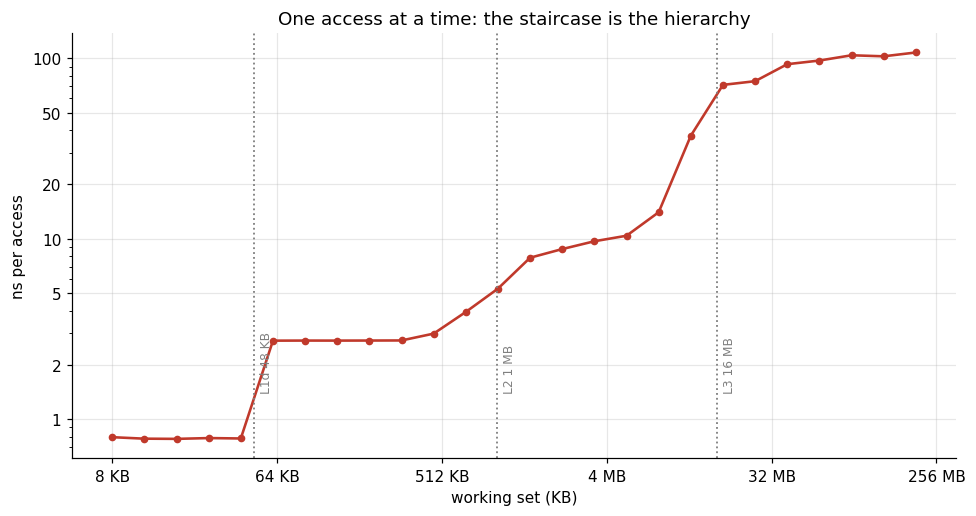

level   fits under      ns  cycles   x L1
L1d          48 KB    0.79       4      1
L2            1 MB    2.73      14      3
L3           16 MB   14.02      71     18
DRAM             —  102.51     507    130


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
xs = [int(r["bytes"])/1024 for r in lat if r["mode"] == "random"]
ys = [float(r["ns"])       for r in lat if r["mode"] == "random"]
ax.plot(xs, ys, "o-", color="#c0392b", ms=4, lw=1.7)

for kb, name in [(48, "L1d 48 KB"), (1024, "L2 1 MB"), (16*1024, "L3 16 MB")]:
    ax.axvline(kb, color="gray", ls=":", lw=1.2)
    ax.text(kb*1.08, 1.4, name, rotation=90, fontsize=8, color="gray", va="bottom")

ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("working set (KB)"); ax.set_ylabel("ns per access")
ax.set_title("One access at a time: the staircase is the hierarchy")
ax.set_xticks([8, 64, 512, 4096, 32768, 262144])
ax.set_xticklabels(["8 KB","64 KB","512 KB","4 MB","32 MB","256 MB"])
ax.set_yticks([1,2,5,10,20,50,100]); ax.set_yticklabels(["1","2","5","10","20","50","100"])
plt.tight_layout(); plt.show()

print(f"{'level':<6}{'fits under':>12}{'ns':>8}{'cycles':>8}{'x L1':>7}")
l1 = float(at("random", 32<<10)["ns"])
for name, size, cap in (("L1d",32<<10,"48 KB"), ("L2",256<<10,"1 MB"),
                        ("L3",8<<20,"16 MB"), ("DRAM",128<<20,"—")):
    r = at("random", size)
    print(f"{name:<6}{cap:>12}{float(r['ns']):>8.2f}{float(r['cycles']):>8.0f}{float(r['ns'])/l1:>7.0f}")

**Read this as a tiling table.** If a loop's inner working set stays under 48 KB it runs at
4 cycles per access; let it grow past 16 MB and the same loop pays ~500. That is the entire
argument for blocking, and the block size you pick is just whichever row you are aiming at.

A DRAM miss costs about **130 L1 hits**. In that time this core could have retired roughly
500 instructions — so one miss can outweigh a great deal of arithmetic.

---
## 4. The line: memory moves in 64-byte units

Nothing moves one byte. Ask for one value and the hardware moves the whole 64-byte line that
contains it. So the question for a loop is not *how many bytes do I need* but **how much of
every line I force the hardware to move do I actually use.**

Source: [`stride_bandwidth.c`](stride_bandwidth.c), part A &rarr; `stride_bandwidth.csv`

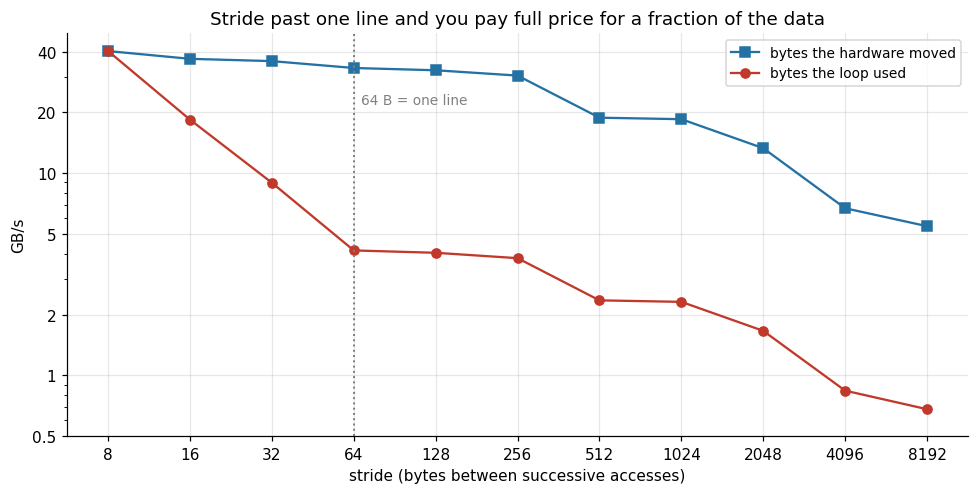

  stride  useful GB/s  moved GB/s   line used
       8         40.2        40.2    12.5%
      16         18.4        36.8    25.0%
      32          9.0        35.9    50.0%
      64          4.2        33.2   100.0%
     128          4.0        32.3   100.0%
     256          3.8        30.4   100.0%


In [5]:
xs = [int(r[1]) for r in stride]
useful  = [float(r[3]) for r in stride]
fetched = [float(r[4]) for r in stride]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(xs, fetched, "s-", color="#2471a3", label="bytes the hardware moved")
ax.plot(xs, useful,  "o-", color="#c0392b", label="bytes the loop used")
ax.axvline(64, color="gray", ls=":", lw=1.3)
ax.text(68, 22, "64 B = one line", fontsize=9, color="gray")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("stride (bytes between successive accesses)"); ax.set_ylabel("GB/s")
ax.set_title("Stride past one line and you pay full price for a fraction of the data")
ax.set_xticks(xs); ax.set_xticklabels([str(x) for x in xs])
ax.set_yticks([0.5,1,2,5,10,20,40]); ax.set_yticklabels(["0.5","1","2","5","10","20","40"])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'stride':>8}{'useful GB/s':>13}{'moved GB/s':>12}   line used")
for r in stride[:6]:
    s = int(r[1])
    print(f"{s:>8}{float(r[3]):>13.1f}{float(r[4]):>12.1f}   {min(s,64)/64*100:>5.1f}%")

Between stride 8 and stride 64 the hardware does the *same* amount of work — a flat ~39 GB/s of
lines moved — while the useful fraction falls by **8x**, which is just `64 / 8`: one useful
double per line.

This is the whole case for structure-of-arrays over array-of-structures, and for making the
contiguous index the innermost loop.

---
## 5. Bandwidth: the ceiling a streaming loop hits

Latency is what *one dependent* access costs. Bandwidth is how much *independent* traffic the
core can keep moving — which is what a well-formed loop actually experiences.

Source: [`stride_bandwidth.c`](stride_bandwidth.c), part B &rarr; `stride_bandwidth.csv`

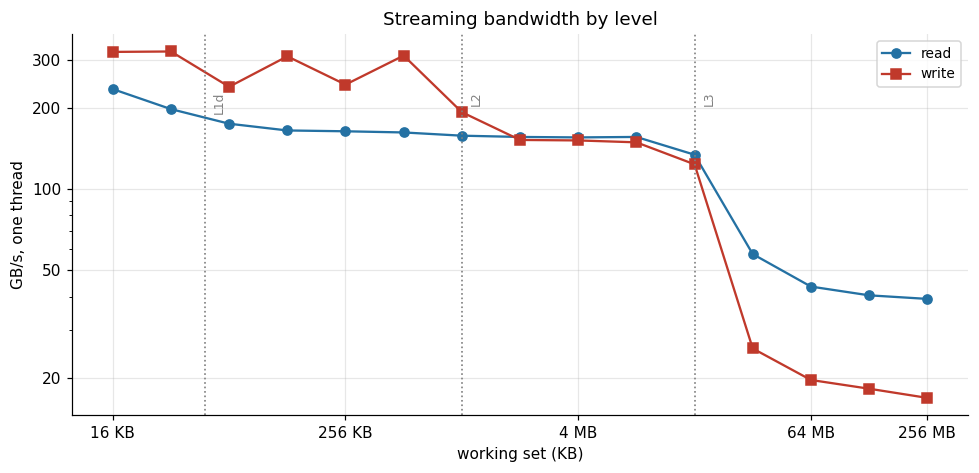

L1 read     234 GB/s      DRAM read    39.2 GB/s   (6.0x)


In [6]:
kb = [int(r[1])/1024 for r in bw]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(kb, [float(r[2]) for r in bw], "o-", color="#2471a3", label="read")
ax.plot(kb, [float(r[3]) for r in bw], "s-", color="#c0392b", label="write")
for k, n in [(48,"L1d"),(1024,"L2"),(16*1024,"L3")]:
    ax.axvline(k, color="gray", ls=":", lw=1.1)
    ax.text(k*1.1, 230, n, fontsize=8, color="gray", rotation=90, va="top")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("working set (KB)"); ax.set_ylabel("GB/s, one thread")
ax.set_title("Streaming bandwidth by level")
ax.set_xticks([16,256,4096,65536,262144])
ax.set_xticklabels(["16 KB","256 KB","4 MB","64 MB","256 MB"])
ax.set_yticks([20,50,100,200,300]); ax.set_yticklabels(["20","50","100","200","300"])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"L1 read  {float(bw[0][2]):>6.0f} GB/s      DRAM read  {float(bw[-1][2]):>6.1f} GB/s"
      f"   ({float(bw[0][2])/float(bw[-1][2]):.1f}x)")

---
## 6. Vector width: when does a wider register help?

The same reduction written three ways — scalar, 256-bit, 512-bit — over the same data. This is
the measurement that decides whether vectorising a given loop is worth anything.

Source: [`vector_width.c`](vector_width.c), part A &rarr; `vector_width.csv`

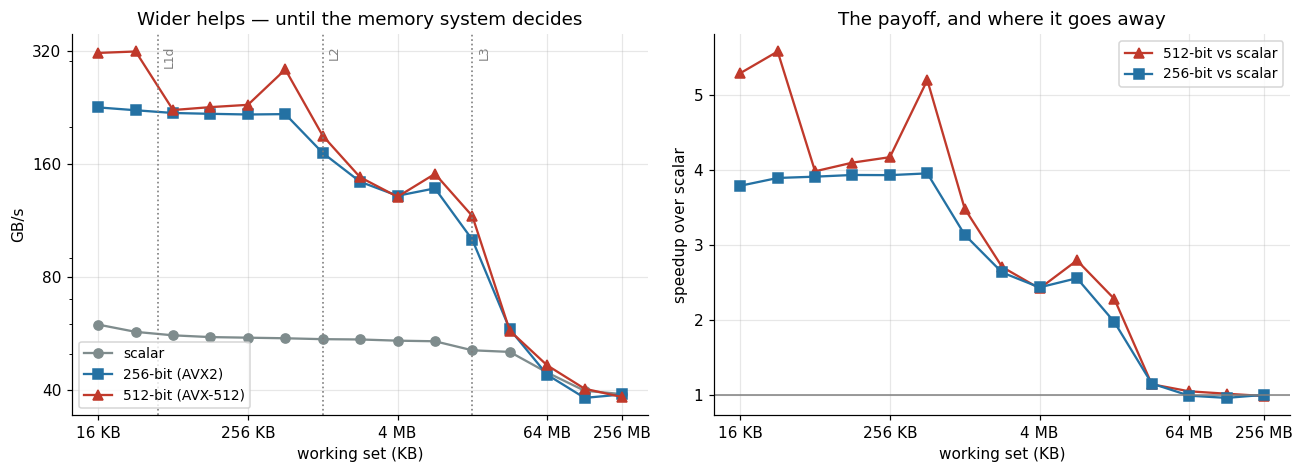

  working set   scalar     AVX2   AVX-512  512 vs scalar
        16 KB     59.7    226.0     315.6           5.3x
         1 MB     54.6    171.0     190.0           3.5x
         8 MB     53.9    137.6     150.4           2.8x
       256 MB     39.0     38.9      38.3           1.0x


In [7]:
b  = [int(r[1])/1024 for r in width]
sc = [float(r[2]) for r in width]
v2 = [float(r[3]) for r in width]
v5 = [float(r[4]) for r in width]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.plot(b, sc, "o-", color="#7f8c8d", label="scalar")
ax.plot(b, v2, "s-", color="#2471a3", label="256-bit (AVX2)")
ax.plot(b, v5, "^-", color="#c0392b", label="512-bit (AVX-512)")
for k, n in [(48,"L1d"),(1024,"L2"),(16*1024,"L3")]:
    ax.axvline(k, color="gray", ls=":", lw=1.1)
    ax.text(k*1.1, 330, n, fontsize=8, color="gray", rotation=90, va="top")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("working set (KB)"); ax.set_ylabel("GB/s")
ax.set_title("Wider helps — until the memory system decides")
ax.set_xticks([16,256,4096,65536,262144])
ax.set_xticklabels(["16 KB","256 KB","4 MB","64 MB","256 MB"])
ax.set_yticks([40,80,160,320]); ax.set_yticklabels(["40","80","160","320"])
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(b, [a/c for a,c in zip(v5,sc)], "^-", color="#c0392b", label="512-bit vs scalar")
ax.plot(b, [a/c for a,c in zip(v2,sc)], "s-", color="#2471a3", label="256-bit vs scalar")
ax.axhline(1, color="gray", lw=1)
ax.set_xscale("log", base=2)
ax.set_xlabel("working set (KB)"); ax.set_ylabel("speedup over scalar")
ax.set_title("The payoff, and where it goes away")
ax.set_xticks([16,256,4096,65536,262144])
ax.set_xticklabels(["16 KB","256 KB","4 MB","64 MB","256 MB"])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'working set':>13}{'scalar':>9}{'AVX2':>9}{'AVX-512':>10}{'512 vs scalar':>15}")
for r in width:
    n = int(r[1]); s_, a_, f_ = float(r[2]), float(r[3]), float(r[4])
    if n in (16<<10, 1<<20, 8<<20, 256<<20):
        lbl = f"{n>>10} KB" if n < (1<<20) else f"{n>>20} MB"
        print(f"{lbl:>13}{s_:>9.1f}{a_:>9.1f}{f_:>10.1f}{f_/s_:>14.1f}x")

**In L1, 512-bit is worth 5.3x over scalar. In DRAM it is worth 1.0x.**

The reason is simple: an L1-resident loop is limited by how many bytes per cycle the core can
load, and a wider register moves more per instruction. A DRAM-resident loop is limited by the
memory system, which does not care how wide your registers are.

Two consequences for a vectorisation lecture:

* **Vectorise the loops that already fit in cache.** Vectorising a memory-bound loop changes
  nothing — you can see it in the right-hand panel dropping to 1.0.
* **Blocking and vectorising are the same project.** Tiling a loop into L1 is what *creates*
  the conditions under which the vector units pay off. Do the tiling first, then the width.

---
## 7. Alignment: a 512-bit load is exactly one line

64-byte lines and 64-byte vectors mean alignment is not a matter of degree. Either every vector
load sits on one line, or every single one straddles two.

Source: [`vector_width.c`](vector_width.c), part B &rarr; `vector_width.csv`

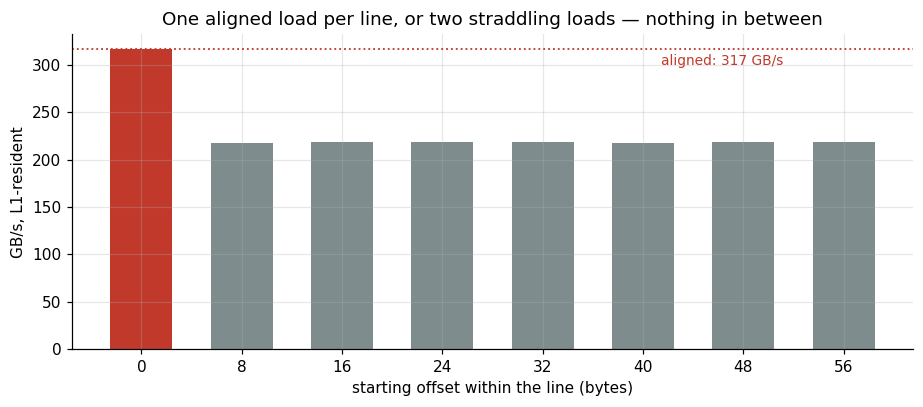

aligned (offset 0)       316.8 GB/s
any other offset         218.6 GB/s  (1.45x slower)

the penalty is flat across offsets 8..56: crossing a line boundary is the whole cost


In [8]:
offs = [int(r[1]) for r in align]
gbps = [float(r[2]) for r in align]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = ["#c0392b" if o == 0 else "#7f8c8d" for o in offs]
ax.bar([str(o) for o in offs], gbps, color=colors, width=0.62)
ax.set_xlabel("starting offset within the line (bytes)")
ax.set_ylabel("GB/s, L1-resident")
ax.set_title("One aligned load per line, or two straddling loads — nothing in between")
ax.axhline(gbps[0], color="#c0392b", ls=":", lw=1.2)
ax.text(6.4, gbps[0]*0.985, f"aligned: {gbps[0]:.0f} GB/s", fontsize=9,
        color="#c0392b", ha="right", va="top")
plt.tight_layout(); plt.show()

print(f"aligned (offset 0)      {gbps[0]:>6.1f} GB/s")
print(f"any other offset        {np.mean(gbps[1:]):>6.1f} GB/s  "
      f"({gbps[0]/np.mean(gbps[1:]):.2f}x slower)")
print("\nthe penalty is flat across offsets 8..56: crossing a line boundary is the whole cost")

This is why `posix_memalign(&p, 64, n)` and `#pragma omp simd aligned(...)` matter, and why the
penalty does not shrink as you get "closer" to aligned. An offset of 56 bytes is no better than
an offset of 8.

---
## 8. The power-of-two trap

The last single-core property worth knowing, because it bites exactly when you start tiling.

L1 has **64 sets**, and a line's set is chosen by address bits 6–11. When a row length is a
power of two, stepping down a column advances the set index by a multiple of 64 — which is to
say, not at all — so a whole column competes for one set of 12 ways while the other 63 sets sit
empty.

Source: [`row_column.c`](row_column.c) &rarr; `row_column.csv`

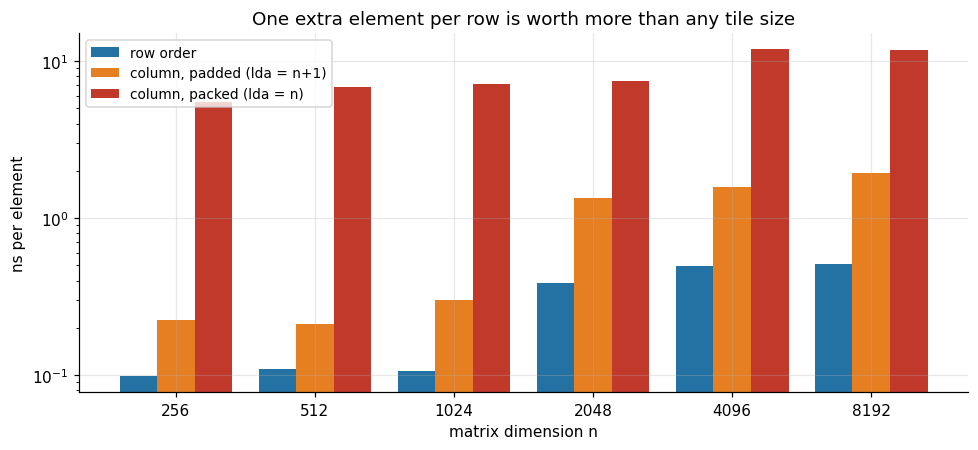

     n      row  col padded  col packed  padding wins
   256    0.099       0.224       5.499         24.5x
   512    0.110       0.212       6.794         32.0x
  1024    0.107       0.299       7.188         24.0x
  2048    0.387       1.342       7.404          5.5x
  4096    0.498       1.576      11.836          7.5x
  8192    0.509       1.933      11.774          6.1x


In [9]:
ns   = sorted({int(r["n"]) for r in rowcol})
pack = {int(r["n"]): r for r in rowcol if int(r["lda"]) == int(r["n"])}
pad  = {int(r["n"]): r for r in rowcol if int(r["lda"]) != int(r["n"])}

fig, ax = plt.subplots(figsize=(9, 4.2))
idx, w = np.arange(len(ns)), 0.27
ax.bar(idx-w, [float(pack[n]["row_ns"]) for n in ns], w, label="row order", color="#2471a3")
ax.bar(idx,   [float(pad[n]["col_ns"])  for n in ns], w, label="column, padded (lda = n+1)", color="#e67e22")
ax.bar(idx+w, [float(pack[n]["col_ns"]) for n in ns], w, label="column, packed (lda = n)",  color="#c0392b")
ax.set_yscale("log"); ax.set_xticks(idx); ax.set_xticklabels([f"{n}" for n in ns])
ax.set_xlabel("matrix dimension n"); ax.set_ylabel("ns per element")
ax.set_title("One extra element per row is worth more than any tile size")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'n':>6}{'row':>9}{'col padded':>12}{'col packed':>12}{'padding wins':>14}")
for n in ns:
    r, cp, ck = float(pack[n]["row_ns"]), float(pad[n]["col_ns"]), float(pack[n]["col_ns"])
    print(f"{n:>6}{r:>9.3f}{cp:>12.3f}{ck:>12.3f}{ck/cp:>13.1f}x")

At n = 1024 the padded column traversal is **24x** faster than the packed one — same loop, same
data, one extra element per row. The rule is not "avoid powers of two" but **how many factors of
two the row length contains measured in cache lines**; a row that is an odd number of lines
reaches every set.

Worked through one bit at a time in [`why_1024_is_slow.html`](why_1024_is_slow.html).

It is worth being precise about what the cache has shrunk *to*. If every address you touch lands
in one set, the only lines available are that set's row — 12 ways — so your effective cache is
**12 x 64 = 768 bytes**, not 48 KB. The other 63 rows are still there, still powered, and
completely unreachable by this loop: you are running in **1/64 of L1d**, 1.6% of it. Generally, a
loop confined to one set gets `ways x line`, which is the capacity divided by the number of sets,
so the more sets a cache has the worse the collapse when you hit this.

Which is why the penalty is as large as it is. A column of a 1024x1024 array of doubles is 8 KB
of data sitting on 1024 separate lines — it would fit in L1 four times over if it were spread
across the sets. Confined to one set, 12 of those lines can be resident at a time, so by the time
the loop comes back around every one has been evicted. The array did not get too big for the
cache; the loop got too narrow for it.


---
## 9. What this means for your loops

| If your loop… | then… |
|---|---|
| walks memory with stride 1 | the prefetcher hides most of the latency; this is the single biggest factor |
| has an inner working set under 48 KB | it runs at 4 cycles per access — this is the tile you are aiming for |
| is already cache-resident | vectorising is worth up to **5.3x**; widen the registers |
| streams from DRAM | vectorising is worth **1.0x**; fix the access pattern or the blocking first |
| reads one field of a struct per iteration | you are using 1/8 of every line — consider SoA |
| indexes a power-of-two 2-D array by column | pad the leading dimension before you do anything else |
| uses vector loads | align the base to 64 bytes, or every load crosses a line |

The ordering matters: **access pattern, then blocking, then width.** A wider vector cannot help
a loop that is waiting for memory, and the measurements above are what that claim rests on.

### The benchmarks behind each section

Every figure above comes from one of four programs in this directory. Each opens with a
comment on what it measures and, more usefully, which measurement trap it had to avoid.

| § | Measures | Program | Emits |
|---|---|---|---|
| 3 | latency vs working set, random and sequential | [`cache_latency.c`](cache_latency.c) | `latency.csv` |
| 4 | line utilisation vs stride | [`stride_bandwidth.c`](stride_bandwidth.c) part A | `stride_bandwidth.csv` |
| 5 | streaming bandwidth by level | [`stride_bandwidth.c`](stride_bandwidth.c) part B | `stride_bandwidth.csv` |
| 6 | scalar vs 256-bit vs 512-bit | [`vector_width.c`](vector_width.c) part A | `vector_width.csv` |
| 7 | load alignment within the line | [`vector_width.c`](vector_width.c) part B | `vector_width.csv` |
| 8 | loop order and leading-dimension padding | [`row_column.c`](row_column.c) | `row_column.csv` |

All four share [`harness.h`](harness.h), which pins to a core, warms it with high-IPC work
before anything is timed, and measures the clock with a dependent add chain. That last part
matters more than it sounds: the governor raises the clock in response to instructions
retiring rather than to the core being busy, so an unwarmed core sits near 3.5 GHz and
returns a stable, reproducible, wrong number.

```
make            # build the benchmarks
make data       # re-run them all and refresh the .csv files
```

The multi-core material — coherence, false sharing, bandwidth scaling across threads — is
deliberately absent; it is in [`cache_hierarchy.ipynb`](cache_hierarchy.ipynb), which draws on
five further programs. The full list is in [`README.memory.md`](README.memory.md).